## 模型测试

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def backtest_and_plot(
    data_new, 
    X_test, 
    y_test, 
    y_pred,
    threshold=0.0001, 
    slippage_rate=0.0005, 
    fee_rate=0.0001,
    bars_per_day=10000,
    days_per_year=252,
    plot_title="Backtest Result"
):
    """
    一键回测+可视化函数

    参数：
    --------
    data_new : pd.DataFrame
        包含完整数据(至少有 'trade_time', 'last_price' 等列)
    X_test   : pd.DataFrame or np.array
        测试集特征的索引，用于定位测试集对应的行
    y_test   : pd.Series or np.array
        测试集的真实收益率
    y_pred   : pd.Series or np.array
        模型对测试集的预测收益率
    threshold : float
        信号阈值(绝对值), 只有当 |y_pred| > threshold 才做多/空
    slippage_rate : float
        滑点费率(百分比)，在本示例中每次交易动作扣除
    fee_rate : float
        手续费费率(百分比)，在本示例中每次交易动作扣除
    bars_per_day : int
        一天内有多少 bar，用于夏普比率的年化
    days_per_year : int
        一年交易日数量(默认 252)
    plot_title : str
        绘图标题

    返回：
    --------
    df_result : pd.DataFrame
        含有回测中间结果的 DataFrame(含 position, equity_curve 等)
    metrics : dict
        包含回测指标如 { 'final_return':..., 'sharpe_ratio':..., 'max_drawdown':... }
    """

    # ========== (A) 合并测试集索引 + 时间 & 价格信息 ==========
    test_index = X_test.index  # 测试集行索引
    df_test = data_new.loc[test_index, ['trade_time', 'last_price']].copy()

    df_test['y_pred'] = y_pred
    df_test['y_true'] = y_test

    # 按时间排序，避免乱序导致的未来函数
    df_test.sort_values('trade_time', inplace=True)

    # ========== (B) 生成交易信号 + 持仓 + 持仓变动 ==========
    df_test['signal'] = 0
    df_test.loc[df_test['y_pred'] >  threshold, 'signal'] = 1
    df_test.loc[df_test['y_pred'] < -threshold, 'signal'] = -1

    # shift(1) 避免未来函数
    df_test['position'] = df_test['signal'].shift(1).fillna(0)

    # 检测持仓变化(开仓/平仓/反手)
    df_test['change_pos'] = df_test['position'].diff().fillna(0).abs()

    # ========== (C) 计算策略收益 & 交易成本(滑点 + 手续费) ==========
    # 1) 原始策略收益(不含成本)
    df_test['strategy_return'] = df_test['position'] * df_test['y_true']

    # 2) 滑点与手续费(均为百分比), only when change_pos != 0
    df_test['slippage_cost'] = np.where(df_test['change_pos'] != 0, slippage_rate, 0)
    df_test['fee_cost']      = np.where(df_test['change_pos'] != 0, fee_rate, 0)

    df_test['transaction_cost'] = df_test['slippage_cost'] + df_test['fee_cost']

    # 3) 扣减成本 => 净收益
    df_test['strategy_return_net'] = df_test['strategy_return'] - df_test['transaction_cost']

    # ========== (D) 资金曲线 & 指标 ==========
    # 累积乘积: (1 + 当期净收益) => equity_curve
    df_test['equity_curve'] = (1 + df_test['strategy_return_net']).cumprod()

    # 最终累计收益率
    final_equity = df_test['equity_curve'].iloc[-1]
    final_return = final_equity - 1

    # 夏普比率(年化)
    mean_r = df_test['strategy_return_net'].mean()
    std_r  = df_test['strategy_return_net'].std()
    annual_factor = np.sqrt(bars_per_day * days_per_year)
    if std_r == 0:
        sharpe_ratio = 0
    else:
        sharpe_ratio = mean_r / std_r * annual_factor

    # 最大回撤
    df_test['roll_max'] = df_test['equity_curve'].cummax()
    df_test['drawdown'] = df_test['equity_curve'] / df_test['roll_max'] - 1
    max_drawdown = df_test['drawdown'].min()

    # 封装回测指标
    metrics = {
        'final_return': final_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown
    }

    # ========== (E) 可视化 ==========
    plt.figure(figsize=(10,6))
    plt.plot(df_test['trade_time'], df_test['equity_curve'], label='Equity Curve', color='blue')
    plt.title(plot_title + f"\n(threshold={threshold}, slip={slippage_rate}, fee={fee_rate})")
    plt.xlabel("Time")
    plt.ylabel("Equity")
    plt.legend()
    plt.show()

    # 返回中间结果和指标，方便进一步分析或比较
    return df_test, metrics

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def backtest_and_plot_many(
    data_new, 
    X_test, 
    y_test, 
    y_pred,
    threshold=0.0001, 
    slippage_rates=[0.0005],  # 允许多个滑点费率
    fee_rates=[0.0001],       # 允许多个手续费费率
    bars_per_day=10000,
    days_per_year=252,
    plot_title="Backtest Result"
):
    """
    进行回测并可视化不同交易成本（滑点费率和手续费费率）下的资金曲线。
    
    参数：
    --------
    data_new : pd.DataFrame
        包含完整数据(至少有 'trade_time', 'last_price' 等列)
    X_test   : pd.DataFrame or np.array
        测试集特征的索引，用于定位测试集对应的行
    y_test   : pd.Series or np.array
        测试集的真实收益率
    y_pred   : pd.Series or np.array
        模型对测试集的预测收益率
    threshold : float
        信号阈值(绝对值), 只有当 |y_pred| > threshold 才做多/空
    slippage_rates : list of float
        滑点费率(百分比)列表，用于比较不同交易成本对策略的影响
    fee_rates : list of float
        手续费费率(百分比)列表，同上
    bars_per_day : int
        一天内有多少 bar，用于夏普比率的年化
    days_per_year : int
        一年交易日数量(默认 252)
    plot_title : str
        绘图标题
    
    返回：
    --------
    results : dict
        以 (slippage_rate, fee_rate) 为键，存储对应的回测结果 DataFrame
    metrics_dict : dict
        以 (slippage_rate, fee_rate) 为键，存储对应的回测指标
    """
    
    results = {}
    metrics_dict = {}
    
    plt.figure(figsize=(10,6))
    
    for slippage_rate in slippage_rates:
        for fee_rate in fee_rates:
            # 复制数据避免污染原数据
            df_test = data_new.loc[X_test.index, ['trade_time', 'last_price']].copy()
            df_test['y_pred'] = y_pred
            df_test['y_true'] = y_test
            df_test.sort_values('trade_time', inplace=True)

            # 生成交易信号
            df_test['signal'] = 0
            df_test.loc[df_test['y_pred'] >  threshold, 'signal'] = 1
            df_test.loc[df_test['y_pred'] < -threshold, 'signal'] = -1
            df_test['position'] = df_test['signal'].shift(1).fillna(0)
            df_test['change_pos'] = df_test['position'].diff().fillna(0).abs()

            # 计算策略收益 & 交易成本
            df_test['strategy_return'] = df_test['position'] * df_test['y_true']
            df_test['slippage_cost'] = np.where(df_test['change_pos'] != 0, slippage_rate, 0)
            df_test['fee_cost'] = np.where(df_test['change_pos'] != 0, fee_rate, 0)
            df_test['transaction_cost'] = df_test['slippage_cost'] + df_test['fee_cost']
            df_test['strategy_return_net'] = df_test['strategy_return'] - df_test['transaction_cost']

            # 资金曲线
            df_test['equity_curve'] = (1 + df_test['strategy_return_net']).cumprod()

            # 计算回测指标
            final_equity = df_test['equity_curve'].iloc[-1]
            final_return = final_equity - 1
            mean_r = df_test['strategy_return_net'].mean()
            std_r  = df_test['strategy_return_net'].std()
            annual_factor = np.sqrt(bars_per_day * days_per_year)
            sharpe_ratio = mean_r / std_r * annual_factor if std_r != 0 else 0
            df_test['roll_max'] = df_test['equity_curve'].cummax()
            df_test['drawdown'] = df_test['equity_curve'] / df_test['roll_max'] - 1
            max_drawdown = df_test['drawdown'].min()

            # 存储结果
            results[(slippage_rate, fee_rate)] = df_test
            metrics_dict[(slippage_rate, fee_rate)] = {
                'final_return': final_return,
                'sharpe_ratio': sharpe_ratio,
                'max_drawdown': max_drawdown
            }
            
            # 绘制资金曲线
            plt.plot(df_test['trade_time'], df_test['equity_curve'], label=f'slip={slippage_rate}, fee={fee_rate}')
    
    plt.title(plot_title)
    plt.xlabel("Time")
    plt.ylabel("Equity")
    plt.legend()
    plt.show()
    
    return results, metrics_dict


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_pickle("features.pkl")
data_new = data.copy()

# 假设 data 是已经加载的 DataFrame
# data['trade_time'] = pd.to_datetime(data['trade_time'])

# 按天分组
data_new['date'] = data_new['trade_time'].dt.date

# 计算3秒后的收益率
data_new['next_price'] = data_new.groupby('date')['last_price'].shift(-6)
data_new['return'] = (data_new['next_price'] - data_new['last_price']) / data_new['last_price']

# 去除隔天的数据
data_new = data_new.dropna(subset=['return'])
data_new.dropna(inplace=True)
target = data_new["return"]
features = data_new.iloc[:, 2:-3]
features.drop(["instrumentid"], inplace=True, axis=1)
features

,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,va2,pb3,...,hurst_ask3,hurst_bid4,hurst_ask4,hurst_bid5,hurst_ask5,hurst_mean_bid,hurst_mean_ask,hurst_mean,hurst_diff_bid,hurst_diff_ask
299,33257.0,66260.0,4.0,66270.0,32.0,66250.0,15.0,66280.0,50.0,66240.0,...,0.857068,0.909162,0.744148,0.839186,0.871240,0.795778,0.837880,0.816829,0.009999,-0.046688
300,33263.0,66260.0,9.0,66270.0,32.0,66250.0,15.0,66280.0,49.0,66240.0,...,0.860451,0.909446,0.718925,0.864240,0.860455,0.800096,0.829110,0.814603,-0.021093,-0.024730
301,33268.0,66250.0,16.0,66270.0,32.0,66240.0,33.0,66280.0,49.0,66230.0,...,0.870936,0.909582,0.727033,0.863495,0.869033,0.806746,0.838006,0.822376,-0.001091,-0.022045
302,33273.0,66250.0,13.0,66260.0,1.0,66240.0,33.0,66270.0,32.0,66230.0,...,0.872643,0.907425,0.720893,0.891744,0.863105,0.818302,0.838801,0.828552,-0.019613,-0.002411
303,33276.0,66250.0,15.0,66270.0,33.0,66240.0,32.0,66280.0,50.0,66230.0,...,0.883905,0.918362,0.736724,0.903147,0.883502,0.815206,0.851787,0.833497,-0.034269,-0.009854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867030,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,5.0,67380.0,...,1.962476,1.369085,0.956806,1.416591,1.827703,1.414568,1.560668,1.487618,0.120139,-0.407447
867031,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,5.0,67380.0,...,1.954204,1.372634,1.218101,1.407802,1.827393,1.423260,1.617463,1.520361,0.087770,-0.322176
867032,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,5.0,67380.0,...,1.931422,1.378978,1.218101,1.407773,1.814126,1.425261,1.626866,1.526063,0.156904,-0.280464
867033,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,5.0,67380.0,...,1.938552,1.389292,1.218101,1.407217,1.822333,1.424188,1.621141,1.522665,0.146108,-0.241924


## 1.基础机器学习模型：岭回归

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
train_data = pd.read_pickle("Train_data.pkl")
test_data = pd.read_pickle("Test_data.pkl")
X_train = train_data.iloc[:,2:-3]
X_test = test_data.iloc[:,2:-3]
y_train = train_data.iloc[:,-1]
y_test = test_data.iloc[:,-1]
ridge = Ridge(alpha=1.0)
#ridge = Lasso(alpha=0.1)
# model fitting
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

# 评估模型
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test,y_pred_ridge)
r2_ridge = r2_score(y_test,y_pred_ridge)
print(f"Ridge Regression MSE: {mse_ridge}")
print(f"Ridge Regression MAE: {mae_ridge}")
print(f"Ridge Regression R2: {r2_ridge}")
print("权重:", ridge.coef_)

Ridge Regression MSE: 1.164161451883468e-08
Ridge Regression MAE: 8.634804464565522e-05
Ridge Regression R2: 0.12377447485203863
权重: [ 1.46124145e-05  2.25588438e-04 -9.13415736e-07 -2.04711249e-04
  6.98877227e-06 -5.71920654e-05 -9.28533858e-07 -3.44040698e-04
  3.61534457e-06  1.46609343e-04  7.12530806e-07 -1.52715894e-05
  3.73096695e-06 -1.12537407e-04  2.56158254e-06  3.33138616e-04
  3.73933863e-06  1.79747368e-05  2.57011275e-06  4.23477491e-04
  1.65882486e-06  0.00000000e+00 -6.01082943e-07 -1.26506774e-07
  8.88395596e-07 -9.33268371e-07  0.00000000e+00  0.00000000e+00
 -2.05248248e-04 -4.04525638e-05 -1.17188155e-05 -6.20966957e-06
  1.82326185e-06  2.78937403e-06 -1.36752915e-06 -4.32548150e-06
  1.74207414e-06 -2.82607613e-07 -1.36752916e-06 -4.32548151e-06
  1.28744902e-05  9.14120751e-06  5.47750387e-06  2.39418958e-06
  4.90306079e-07 -3.03106402e-06  6.73284272e-06  4.22316666e-05
 -6.28863420e-07 -2.56660834e-07 -9.43003583e-08  7.20140257e-06
 -4.25773503e-06 -6.31

In [8]:
y_pred_ridge.std()

np.float64(7.18061994661365e-05)

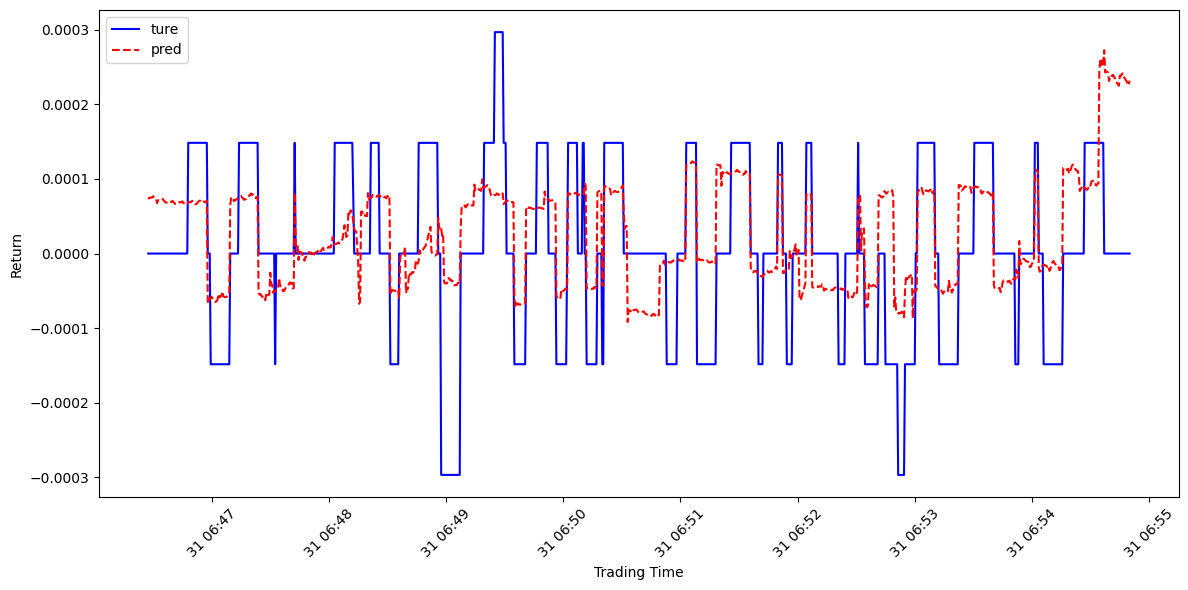

In [ ]:
import matplotlib.pyplot as plt

# 假设你的测试数据 DataFrame 包含 'trade_time' 列（时间戳）
# 这里提取交易时间，确保它与 y_pred 和 y_true 数组的顺序一致
y_test_last = y_test.tail(1000) if hasattr(y_test, 'tail') else y_test[-1000:]
y_pred_last = y_pred_ridge[-1000:]
trade_time = test_data['trade_time'].tail(1000).values  # 或者 test_data['trade_time']

# 绘图
plt.figure(figsize=(12, 6))
plt.plot(trade_time, y_test_last, label="ture", color='blue', linestyle='-')
plt.plot(trade_time, y_pred_last, label="pred", color='red', linestyle='--')
plt.xlabel("Trading Time")   # X轴为交易时间
plt.ylabel("Return")  # 根据实际情况修改Y轴标签
plt.legend()
plt.xticks(rotation=45)  # 如果时间标签较长，可以旋转一下以便阅读
plt.tight_layout()  # 自动调整子图参数以防止标签被遮挡
plt.show()

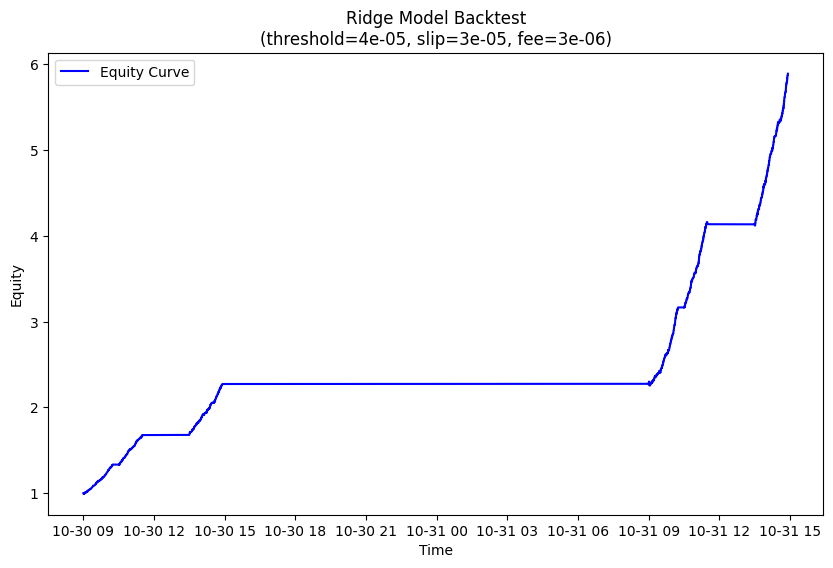

(                             trade_time  last_price    y_pred    y_true  \
 764461        2023-10-30 09:00:03+08:00     67340.0  0.000017 -0.000446   
 764462 2023-10-30 09:00:03.500000+08:00     67340.0  0.000057 -0.000446   
 764463        2023-10-30 09:00:04+08:00     67340.0  0.000050 -0.000446   
 764464 2023-10-30 09:00:04.500000+08:00     67350.0 -0.000037 -0.000594   
 764465        2023-10-30 09:00:05+08:00     67350.0 -0.000027 -0.000594   
 ...                                 ...         ...       ...       ...   
 845437        2023-10-31 14:54:48+08:00     67410.0  0.000233  0.000000   
 845438 2023-10-31 14:54:48.500000+08:00     67410.0  0.000231  0.000000   
 845439        2023-10-31 14:54:49+08:00     67410.0  0.000227  0.000000   
 845440 2023-10-31 14:54:49.500000+08:00     67410.0  0.000225  0.000000   
 845441        2023-10-31 14:54:50+08:00     67410.0  0.000232  0.000000   
 
         signal  position  change_pos  strategy_return  slippage_cost  \
 764461      

In [10]:
backtest_and_plot(data_new=data_new, X_test=X_test, y_test=y_test, y_pred=y_pred_ridge, threshold=4e-5,  slippage_rate=3e-5,  fee_rate=3e-6, bars_per_day=10000, days_per_year=252,  plot_title="Ridge Model Backtest" )

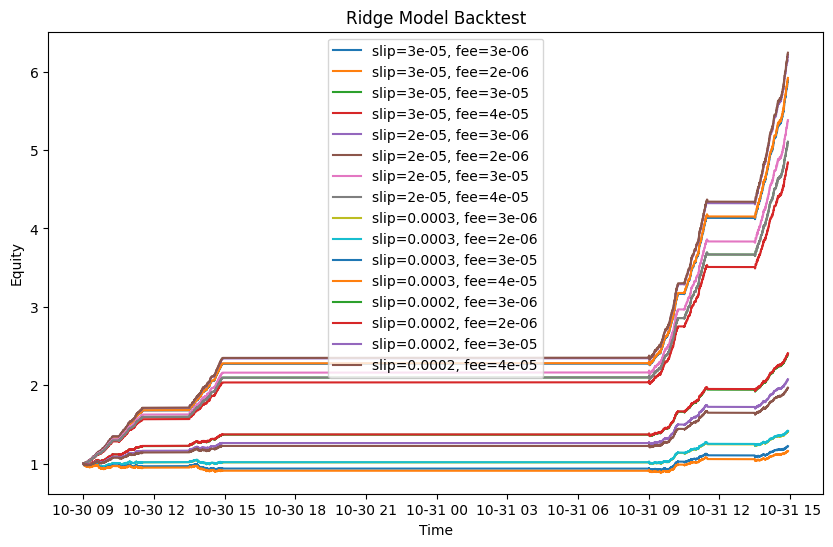

({(3e-05,
   3e-06):                              trade_time  last_price    y_pred    y_true  \
  764461        2023-10-30 09:00:03+08:00     67340.0  0.000017 -0.000446   
  764462 2023-10-30 09:00:03.500000+08:00     67340.0  0.000057 -0.000446   
  764463        2023-10-30 09:00:04+08:00     67340.0  0.000050 -0.000446   
  764464 2023-10-30 09:00:04.500000+08:00     67350.0 -0.000037 -0.000594   
  764465        2023-10-30 09:00:05+08:00     67350.0 -0.000027 -0.000594   
  ...                                 ...         ...       ...       ...   
  845437        2023-10-31 14:54:48+08:00     67410.0  0.000233  0.000000   
  845438 2023-10-31 14:54:48.500000+08:00     67410.0  0.000231  0.000000   
  845439        2023-10-31 14:54:49+08:00     67410.0  0.000227  0.000000   
  845440 2023-10-31 14:54:49.500000+08:00     67410.0  0.000225  0.000000   
  845441        2023-10-31 14:54:50+08:00     67410.0  0.000232  0.000000   
  
          signal  position  change_pos  strategy_retur

In [ ]:
backtest_and_plot_many(data_new=data_new, X_test=X_test, y_test=y_test, y_pred=y_pred_ridge, threshold=4e-5,  slippage_rates=[3e-5,2e-5,3e-4,2e-4],  fee_rates=[3e-6,2e-6,3e-5,4e-5], bars_per_day=10000, days_per_year=252,  plot_title="Ridge Model Backtest" )

## SVM模型

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn import svm

train_data = pd.read_pickle("Train_data.pkl")
test_data = pd.read_pickle("Test_data.pkl")
X_train = train_data.iloc[:,2:-3]
X_test = test_data.iloc[:,2:-3]
y_train = train_data.iloc[:,-1]
y_test = test_data.iloc[:,-1]
SVM = svm.SVR(kernel='rbf',C = 10)
# model fitting
SVM.fit(X_train, y_train)

y_pred_SVM = SVM.predict(X_test)

# 评估模型
mse_SVM = mean_squared_error(y_test, y_pred_SVM)
mae_SVM = mean_absolute_error(y_test,y_pred_SVM)
r2_SVM = r2_score(y_test,y_pred_SVM)
print(f"SVM Regression MSE: {mse_SVM}")
print(f"SVM Regression MAE: {mae_SVM}")
print(f"SVM Regression R2: {r2_SVM}")

SVM Regression MSE: 1.1217006359722622e-06
SVM Regression MAE: 0.001056440374106766
SVM Regression R2: -198.08175214979516


In [13]:
y_pred_SVM.std()

np.float64(0.0)

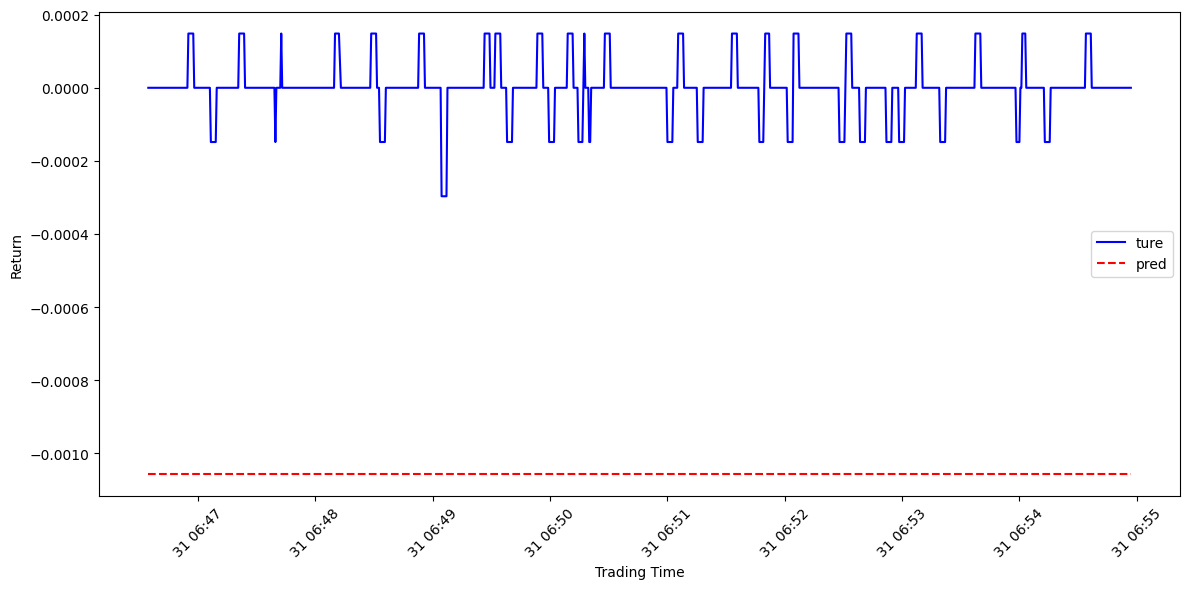

In [14]:
import matplotlib.pyplot as plt

# 假设你的测试数据 DataFrame 包含 'trade_time' 列（时间戳）
# 这里提取交易时间，确保它与 y_pred 和 y_true 数组的顺序一致
y_test_last = y_test.tail(1000) if hasattr(y_test, 'tail') else y_test[-1000:]
y_pred_last = y_pred_SVM[-1000:]
trade_time = test_data['trade_time'].tail(1000).values  # 或者 test_data['trade_time']

# 绘图
plt.figure(figsize=(12, 6))
plt.plot(trade_time, y_test_last, label="ture", color='blue', linestyle='-')
plt.plot(trade_time, y_pred_last, label="pred", color='red', linestyle='--')
plt.xlabel("Trading Time")   # X轴为交易时间
plt.ylabel("Return")  # 根据实际情况修改Y轴标签
plt.legend()
plt.xticks(rotation=45)  # 如果时间标签较长，可以旋转一下以便阅读
plt.tight_layout()  # 自动调整子图参数以防止标签被遮挡
plt.show()

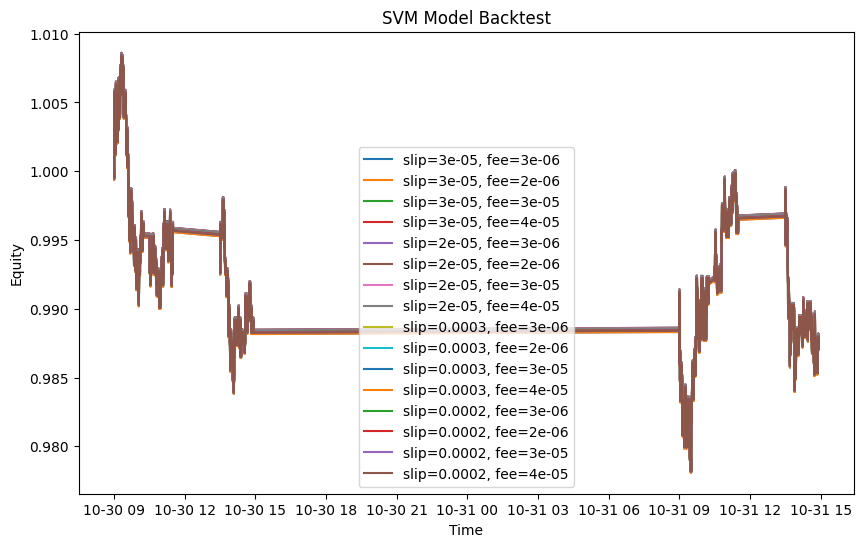

In [15]:
df_result, metrics = backtest_and_plot_many(data_new=data_new, X_test=X_test, y_test=y_test, y_pred=y_pred_SVM,threshold=1e-6, slippage_rates=[3e-5,2e-5,3e-4,2e-4],  fee_rates=[3e-6,2e-6,3e-5,4e-5], bars_per_day=10000,days_per_year=252, plot_title="SVM Model Backtest")

## Decision Tree

In [16]:
from sklearn import tree #导入需要的模块
clf = tree.DecisionTreeRegressor(max_depth=5,max_features=20) #实例化模型对象
clf = clf.fit(X_train,y_train) #用训练集数据训练模型
y_pred_Tree = clf.predict(X_test)

# 评估模型
mse_Tree = mean_squared_error(y_test, y_pred_Tree)
mae_Tree = mean_absolute_error(y_test,y_pred_Tree)
r2_Tree = r2_score(y_test,y_pred_Tree)
print(f"Tree Regression MSE: {mse_Tree}")
print(f"Tree Regression MAE: {mae_Tree}")
print(f"Tree Regression R2: {r2_Tree}")


Tree Regression MSE: 5.618766342291382e-09
Tree Regression MAE: 3.312458775502724e-05
Tree Regression R2: 0.0027697119257718006


In [17]:
y_pred_Tree.std()

np.float64(1.1901006622729204e-05)

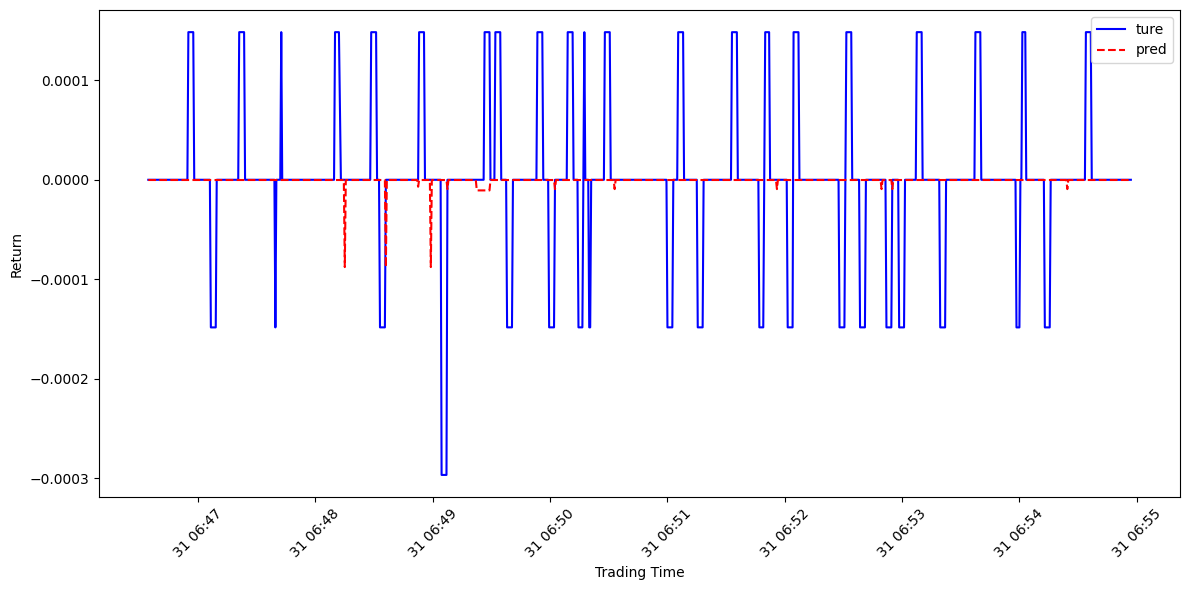

In [18]:
import matplotlib.pyplot as plt

# 假设你的测试数据 DataFrame 包含 'trade_time' 列（时间戳）
# 这里提取交易时间，确保它与 y_pred 和 y_true 数组的顺序一致
y_test_last = y_test.tail(1000) if hasattr(y_test, 'tail') else y_test[-1000:]
y_pred_last = y_pred_Tree[-1000:]
trade_time = test_data['trade_time'].tail(1000).values  # 或者 test_data['trade_time']

# 绘图
plt.figure(figsize=(12, 6))
plt.plot(trade_time, y_test_last, label="ture", color='blue', linestyle='-')
plt.plot(trade_time, y_pred_last, label="pred", color='red', linestyle='--')
plt.xlabel("Trading Time")   # X轴为交易时间
plt.ylabel("Return")  # 根据实际情况修改Y轴标签
plt.legend()
plt.xticks(rotation=45)  # 如果时间标签较长，可以旋转一下以便阅读
plt.tight_layout()  # 自动调整子图参数以防止标签被遮挡
plt.show()

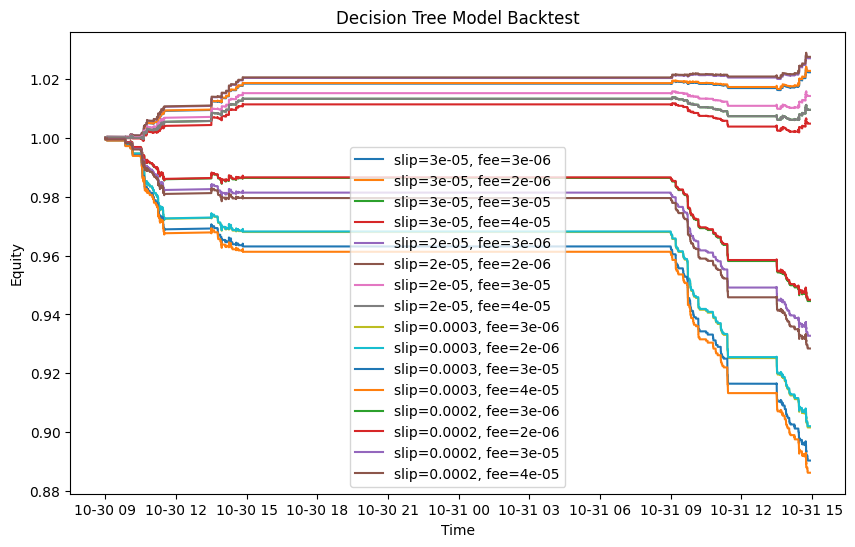

In [19]:
df_result, metrics = backtest_and_plot_many(data_new=data_new, X_test=X_test, y_test=y_test, y_pred=y_pred_Tree,threshold=4e-5, slippage_rates=[3e-5,2e-5,3e-4,2e-4],  fee_rates=[3e-6,2e-6,3e-5,4e-5], bars_per_day=10000,days_per_year=252, plot_title="Decision Tree Model Backtest")

## 2.lightgbm树模型

In [20]:
#Lightgbm Model
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
# 初始化参数
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# 用于存储每个模型的预测结果
test_predictions = np.zeros((X_test.shape[0], n_folds))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Training fold {fold + 1}")
    
    # 划分训练集和验证集
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    train_data_fold = lgb.Dataset(X_train_fold, label=y_train_fold)
    valid_data_fold = lgb.Dataset(X_val_fold, label=y_val_fold, reference=train_data_fold)

# 设置模型参数
    params = {
        'boosting_type': 'gbdt',  # 提升类型
        'objective': 'regression',  # 目标函数
        'metric': 'rmse',  # 评估指标
        'num_leaves': 31,  # 叶子节点数
        'learning_rate': 0.01,  # 学习率
        'feature_fraction': 0.9,  # 特征子采样
        'bagging_fraction': 0.8,  # 数据子采样
        'bagging_freq': 5,  # 每5次迭代执行一次bagging
        'verbose': 0  # 控制输出信息
    }
    callbacks = [lgb.log_evaluation(period=1), lgb.early_stopping(stopping_rounds=5)]
    # 训练模型
    num_round = 100  # 迭代次数
    bst = lgb.train(params, train_data_fold, num_round, valid_sets=[valid_data_fold],callbacks=callbacks)

    # 使用训练好的模型进行预测
    y_pred = bst.predict(X_test, num_iteration=bst.best_iteration)
    test_predictions[:,fold] = y_pred 

# 输出预测结果
y_pred = test_predictions.mean(axis = 1)

mse_lgb = mean_squared_error(y_test, y_pred)
mae_lgb = mean_absolute_error(y_test,y_pred)
r2_lgb = r2_score(y_test,y_pred)
print("预测值:", y_pred)
print("真实值：",y_test)
print(f"lightgbm MSE: {mse_lgb}")
print(f"lightgbm MAE: {mae_lgb}")
print(f"lightgbm r2: {r2_lgb}")

Training fold 1
[1]	valid_0's rmse: 9.27052e-05
Training until validation scores don't improve for 5 rounds
[2]	valid_0's rmse: 9.25036e-05
[3]	valid_0's rmse: 9.23056e-05
[4]	valid_0's rmse: 9.22765e-05
[5]	valid_0's rmse: 9.20832e-05
[6]	valid_0's rmse: 9.1892e-05
[7]	valid_0's rmse: 9.17038e-05
[8]	valid_0's rmse: 9.15194e-05
[9]	valid_0's rmse: 9.13385e-05
[10]	valid_0's rmse: 9.11602e-05
[11]	valid_0's rmse: 9.09858e-05
[12]	valid_0's rmse: 9.08147e-05
[13]	valid_0's rmse: 9.06466e-05
[14]	valid_0's rmse: 9.04812e-05
[15]	valid_0's rmse: 9.03178e-05
[16]	valid_0's rmse: 9.01599e-05
[17]	valid_0's rmse: 9.0005e-05
[18]	valid_0's rmse: 8.98519e-05
[19]	valid_0's rmse: 8.97022e-05
[20]	valid_0's rmse: 8.95555e-05
[21]	valid_0's rmse: 8.94106e-05
[22]	valid_0's rmse: 8.92688e-05
[23]	valid_0's rmse: 8.91279e-05
[24]	valid_0's rmse: 8.89893e-05
[25]	valid_0's rmse: 8.88533e-05
[26]	valid_0's rmse: 8.87205e-05
[27]	valid_0's rmse: 8.85887e-05
[28]	valid_0's rmse: 8.84606e-05
[29]	valid_

In [21]:
y_pred.std()

np.float64(2.646581645093705e-05)

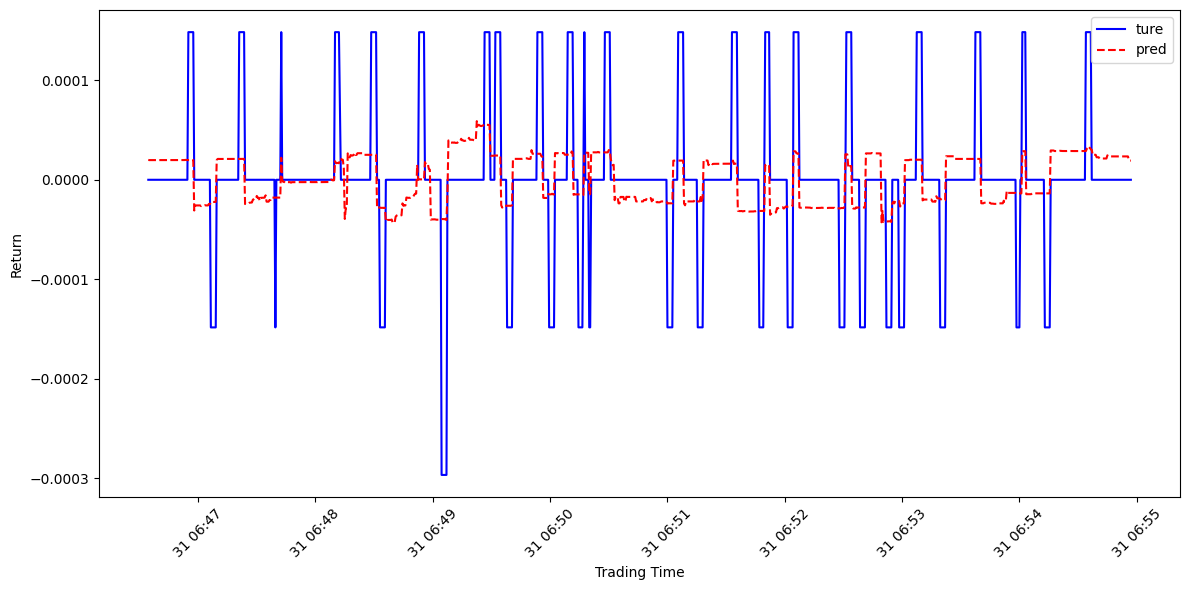

In [22]:
import matplotlib.pyplot as plt

# 假设你的测试数据 DataFrame 包含 'trade_time' 列（时间戳）
# 这里提取交易时间，确保它与 y_pred 和 y_true 数组的顺序一致
y_test_last = y_test.tail(1000) if hasattr(y_test, 'tail') else y_test[-1000:]
y_pred_last = y_pred[-1000:]
trade_time = test_data['trade_time'].tail(1000).values  # 或者 test_data['trade_time']

# 绘图
plt.figure(figsize=(12, 6))
plt.plot(trade_time, y_test_last, label="ture", color='blue', linestyle='-')
plt.plot(trade_time, y_pred_last, label="pred", color='red', linestyle='--')
plt.xlabel("Trading Time")   # X轴为交易时间
plt.ylabel("Return")  # 根据实际情况修改Y轴标签
plt.legend()
plt.xticks(rotation=45)  # 如果时间标签较长，可以旋转一下以便阅读
plt.tight_layout()  # 自动调整子图参数以防止标签被遮挡
plt.show()

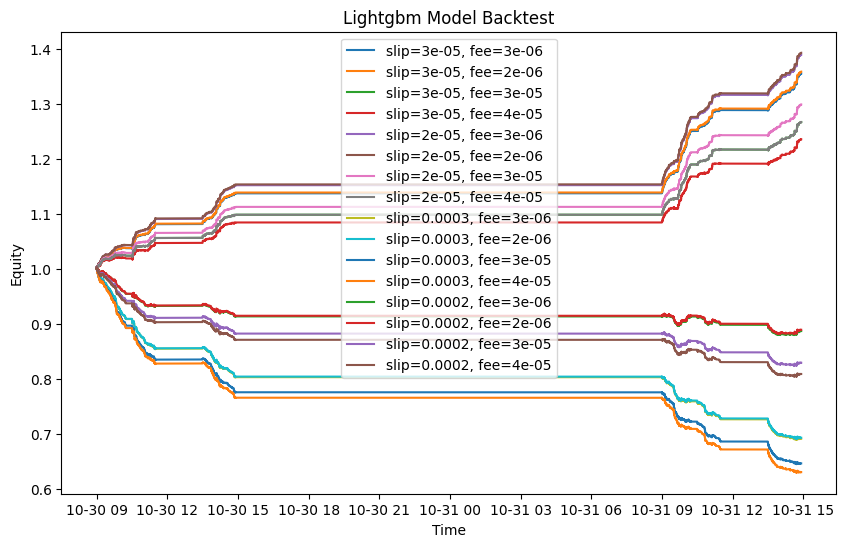

In [23]:
df_result, metrics = backtest_and_plot_many(data_new=data_new, X_test=X_test, y_test=y_test, y_pred=y_pred,threshold=3e-5, slippage_rates=[3e-5,2e-5,3e-4,2e-4],  fee_rates=[3e-6,2e-6,3e-5,4e-5], bars_per_day=10000,days_per_year=252, plot_title="Lightgbm Model Backtest")

In [24]:
def backtest_multiple_models(
    data_new, 
    X_test,
    y_test,
    model_preds_dict,  # { '模型名称': y_pred值 }, 可以传多个预测结果
    threshold=0.0001,
    slippage_rate=0.0005,
    fee_rate=0.0001,
    bars_per_day=10000,
    days_per_year=252
):
    """
    传入多个模型的预测结果，逐一回测并输出一个汇总 DataFrame
    """
    result_records = []
    for model_name, y_pred in model_preds_dict.items():
        df_result, metrics = backtest_and_plot(
            data_new=data_new,
            X_test=X_test,
            y_test=y_test,
            y_pred=y_pred,
            threshold=threshold,
            slippage_rate=slippage_rate,
            fee_rate=fee_rate,
            bars_per_day=bars_per_day,
            days_per_year=days_per_year,
            plot_title=f"{model_name} Backtest"
        )
        
        # 将该模型的回测 metrics + 其它想要补充的信息，存入 result_records
        result_records.append((model_name, metrics['final_return'], metrics['sharpe_ratio'], metrics['max_drawdown']))

    # 构建一个汇总 DataFrame
    df_metrics = pd.DataFrame(
        result_records,
        columns=["model_name", "final_return", "sharpe_ratio", "max_drawdown"]
    ).set_index("model_name")
    
    return df_metrics

In [25]:
model_preds = {
    "Ridge": y_pred_ridge,
    "SVM": y_pred_SVM,
    "Tree":y_pred_Tree,
    "Lightgbm":y_pred
}
df_metrics_all = backtest_multiple_models(
    data_new=data_new,
    X_test=X_test,
    y_test=y_test,
    model_preds_dict=model_preds,
    threshold=4e-5,
    slippage_rate=3e-5,
    fee_rate=3e-6,
    bars_per_day=10000,
    days_per_year=252
)
print(df_metrics_all)

ValueError: Length of values (51705) does not match length of index (51733)

In [ ]:
df_metrics_all

## 神经网络模型

## 1.简单的MLP神经网络

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 定义MLP模型
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.1):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.fc3 = nn.Linear(64, output_dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 输入层到第一隐藏层
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        # 第一隐藏层到第二隐藏层
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        # 第二隐藏层到输出层
        x = self.fc3(x)
        return x

# 假设输入数据的维度为 (batch_size, feature_dim)
input_dim = 78  # 特征维度
hidden_dim = 128  # 隐藏层维度
output_dim = 1  # 输出维度（收益率）

# 创建模型实例并移动到CUDA
model = MLP(input_dim, hidden_dim, output_dim).to(device)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

X_train_tensor = torch.tensor(X_train.values,dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).to(device)
y_train_tensor = 1000*y_train_tensor
# 创建DataLoader
train_data = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_data, batch_size=4096, shuffle=True)

# 训练模型
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = []
    for batch_X, batch_y in train_loader:
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss.append(loss.item())
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {np.mean(total_loss):.9f}')

# 测试模型
model.eval()
with torch.no_grad():
    test_X_tensor = torch.tensor(X_test.values,dtype=torch.float32).to(device)
    y_pred = model(test_X_tensor).cpu().numpy()

y_test_new = 1000*y_test    
mse_MLP = mean_squared_error(y_test_new, y_pred)
mae_MLP = mean_absolute_error(y_test_new,y_pred)
r2_MLP = r2_score(y_test_new,y_pred)
print(f"MLP MSE: {mse_MLP}")
print(f"MLP MAE: {mae_MLP}")
print(f"MLP R2: {r2_MLP}")

## 2.时序神经网络

In [ ]:
#创建时序数据
import pandas as pd
import pickle
import numpy as np
sequence_length = 6
train_data = pd.read_pickle("Train_data.pkl")
test_data = pd.read_pickle("Test_data.pkl")
# 创建序列数据
def create_sequences(data, sequence_length):
    for date, group in data.groupby('date'):
        print(date)
        group = group.sort_values('trade_time')
        sequences = []
        targets = group['return'].values[6:]
        for i in range(6):
            if i<6:
                group_shift = group.iloc[i:-6+i,2:-3]
            else:
                group_shift = group.iloc[i:,2:-3]
            # group_shift = group.rolling(6).mean()
            # indexes = [i for i in range(5,group_shift.shape[0]) if i%6==0]   
            sequences.append(group_shift.values)
        sequences = np.array(sequences)
        sequences = np.transpose(sequences, (1, 0,2))
        print(sequences.shape,targets.shape)
        with open(str(date)+"_x.pkl","wb") as file:
            pickle.dump(sequences,file)
        with open(str(date)+"_y.pkl","wb") as file:
            pickle.dump(targets,file)
    return

create_sequences(train_data, sequence_length)
create_sequences(test_data, sequence_length)

In [ ]:
#创建时序数据
import pandas as pd
import pickle
import numpy as np
sequence_length = 6
train_data = pd.read_pickle("Train_data.pkl")
test_data = pd.read_pickle("Test_data.pkl")
# 创建序列数据
def create_sequences_new(data, sequence_length):
    for date, group in data.groupby('date'):
        print(date)
        group = group.sort_values('trade_time')
        sequences = []
        targets = group['return'].values[10::6]
        group_x = group.iloc[:,2:-3]
        group_x = group_x.rolling(10).mean()
        group_x = group_x.iloc[10:]
        group_x = group_x[::6]
        for i in range(6):
            if i<6:
                group_shift = group_x.iloc[i:-6+i]
            else:
                group_shift = group_x.iloc[i:]
            sequences.append(group_shift.values)
        sequences = np.array(sequences)
        sequences = np.transpose(sequences, (1, 0,2))
        targets = targets[6:]
        print(sequences.shape,targets.shape)
        with open(str(date)+"_x.pkl","wb") as file:
            pickle.dump(sequences,file)
        with open(str(date)+"_y.pkl","wb") as file:
            pickle.dump(targets,file)
    return

create_sequences_new(train_data, sequence_length)
create_sequences_new(test_data, sequence_length)

## 基于自注意力机制的门控单元网络（SA_GRU）

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

# 划分训练集和测试集
# X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)
class SelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(SelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        assert self.head_dim * num_heads == embed_dim, "embed_dim must be divisible by num_heads"

        # 线性变换层，用于生成 Q, K, V
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

        # 输出线性变换层
        self.out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        batch_size, seq_len, embed_dim = x.size()

        # 生成 Q, K, V
        Q = self.query(x)  # (batch_size, seq_len, embed_dim)
        K = self.key(x)    # (batch_size, seq_len, embed_dim)
        V = self.value(x)  # (batch_size, seq_len, embed_dim)

        # 将 Q, K, V 拆分为多个头
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)  # (batch_size, num_heads, seq_len, head_dim)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)  # (batch_size, num_heads, seq_len, head_dim)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)  # (batch_size, num_heads, seq_len, head_dim)

        # 计算注意力分数
        scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))  # (batch_size, num_heads, seq_len, seq_len)
        attention_weights = F.softmax(scores, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)

        # 应用注意力权重到 V
        output = torch.matmul(attention_weights, V)  # (batch_size, num_heads, seq_len, head_dim)

        # 合并多头
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)  # (batch_size, seq_len, embed_dim)

        # 输出线性变换
        output = self.out(output)  # (batch_size, seq_len, embed_dim)

        return output
    
class SA_GRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, heads, dropout):
        super(SA_GRU, self).__init__()
        self.linear = nn.Linear(input_dim, hidden_dim)
        self.attention = SelfAttention(hidden_dim, heads)
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()

    def forward(self, x):
        # Linear transformation
        x = self.linear(x)
        x = self.activation(x)
        x = self.dropout(x)

        # Self-attention
        N, seq_len, _ = x.shape
        x = self.attention(x)
        x = self.dropout(x)

        # GRU
        x, _ = self.gru(x)
        x = self.dropout(x)

        # Output layer
        x = self.fc(x[:, -1, :])  # Take the last time step's output
        return x
# 初始化模型
# Hyperparameters
input_size = 78
hidden_size = 128
output_size = 1  # Predicting a single value (e.g., stock price)
num_layers = 2
heads = 4
dropout = 0.1

# Instantiate the model
device = "cuda"
model = SA_GRU(input_size, hidden_size, output_size, num_layers, heads, dropout).to(device)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.025)

# 转换为PyTorch张量
 
# X_train_tensor = torch.tensor(X_train_seq,  dtype=torch.float32).to(device)
# y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).view(-1, 1).to(device)
# X_test_tensor = torch.tensor(X_test_seq,  dtype=torch.float32).to(device)
# y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).view(-1, 1)
# dataset = TensorDataset(X_train_tensor, y_train_tensor)
# dataloader = DataLoader(dataset, batch_size=4096, shuffle=True)
# 训练模型
num_epochs = 10
datelist = train_data.date.unique()
date_len = len(datelist)
for epoch in range(num_epochs):
    print(epoch)
    for date in datelist:
        if str(date)=="2023-10-21" or str(date)=="2023-10-28":
            continue
        with open(str(date)+"_x.pkl","rb") as file:
            date_x = pickle.load(file)
        with open(str(date)+"_y.pkl","rb") as file:
            date_y = pickle.load(file)
        X_tensor = torch.tensor(date_x,dtype=torch.float32).to(device)
        y_tensor = torch.tensor(date_y,dtype=torch.float32).to(device)
        y_tensor = (y_tensor-y_tensor.mean()) / y_tensor.std()
        train_data_nn = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(train_data_nn, batch_size=256, shuffle=True)
        model.train()
        for batch_X, batch_y in train_loader:
            # 前向传播
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            # 反向传播和优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f'Epoch [{epoch+1}/10], date:{str(date)},Loss: {loss.item():.9f}')
# 预测
with open("2023-10-30_x.pkl","rb") as file:
    date_x1 = pickle.load(file)
with open("2023-10-30_y.pkl","rb") as file:
    date_y1 = pickle.load(file)
with open("2023-10-31_x.pkl","rb") as file:
    date_x2 = pickle.load(file)
with open("2023-10-31_y.pkl","rb") as file:
    date_y2 = pickle.load(file)
X_test_tensor = torch.tensor(np.concatenate((date_x1,date_x2),axis=0),dtype=torch.float32).to(device)
y_test_tensor = np.concatenate((date_y1,date_y2),axis=0)
y_test_tensor = (y_test_tensor-y_test_tensor.mean())/y_test_tensor.std()
model.eval()

with torch.no_grad():
    y_pred_SAGRU = model(X_test_tensor).cpu().numpy()
# 评估模型
mse_SAGRU = mean_squared_error(y_test_tensor, y_pred_SAGRU)
mae_SAGRU = mean_absolute_error(y_test_tensor,y_pred_SAGRU)
r2_SAGRU = r2_score(y_test_tensor,y_pred_SAGRU)
print(f"MSE: {mse_SAGRU}")
print(f"MAE: {mae_SAGRU}")
print(f"R2: {r2_SAGRU}")

## 4.Transformers

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

import torch
import torch.nn as nn
import torch.optim as optim

class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim, num_heads, num_layers, dropout=0.1):
        super(TransformerModel, self).__init__()
        
        # Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim1, nhead=num_heads, dim_feedforward=hidden_dim1, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Fully connected layers
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, output_dim)
        
        # Activation and Dropout
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        x = self.relu(self.fc1(x))
        # Permute to (seq_len, batch_size, input_dim) for Transformer
        x = x.permute(1, 0, 2)
        # Transformer Encoder
        transformer_output = self.transformer_encoder(x)
        
        # Permute back to (batch_size, seq_len, input_dim)
        transformer_output = transformer_output.permute(1, 0, 2)
        
        # Take the last time step's output
        last_time_step_output = transformer_output[:, -1, :]
        
        # Fully connected layers
        x = self.relu(self.fc2(last_time_step_output))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x

# Hyperparameters
input_dim = 78  # Number of features
hidden_dim1 = 128
hidden_dim2 = 64
output_dim = 1  # Predicting futures return
num_heads = 8  # Number of attention heads
num_layers = 2  # Number of transformer layers
dropout = 0.1

# Initialize model
device = "cuda"
model = TransformerModel(input_dim, hidden_dim1, hidden_dim2, output_dim, num_heads, num_layers, dropout).to(device)


# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.025)

# 转换为PyTorch张量
 
# X_train_tensor = torch.tensor(X_train_seq,  dtype=torch.float32).to(device)
# y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).view(-1, 1).to(device)
# X_test_tensor = torch.tensor(X_test_seq,  dtype=torch.float32).to(device)
# y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).view(-1, 1)
# dataset = TensorDataset(X_train_tensor, y_train_tensor)
# dataloader = DataLoader(dataset, batch_size=4096, shuffle=True)
# 训练模型
num_epochs = 10
datelist = train_data.date.unique()
date_len = len(datelist)
for epoch in range(num_epochs):
    print(epoch)
    for date in datelist:
        with open(str(date)+"_x.pkl","rb") as file:
            date_x = pickle.load(file)
        with open(str(date)+"_y.pkl","rb") as file:
            date_y = pickle.load(file)
        X_tensor = torch.tensor(date_x,dtype=torch.float32).to(device)
        y_tensor = torch.tensor(date_y,dtype=torch.float32).to(device)
        y_tensor = y_tensor*1000
        train_data = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
        model.train()
        total_loss = []
        for batch_X, batch_y in train_loader:
            # 前向传播
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            # 反向传播和优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss.append(loss.item())
        print(f'Epoch [{epoch+1}/10], date:{str(date)},Loss: {np.mean(total_loss):.9f}')
# 预测
with open("2023-10-30_x.pkl","rb") as file:
    date_x1 = pickle.load(file)
with open("2023-10-30_y.pkl","rb") as file:
    date_y1 = pickle.load(file)
with open("2023-10-31_x.pkl","rb") as file:
    date_x2 = pickle.load(file)
with open("2023-10-31_y.pkl","rb") as file:
    date_y2 = pickle.load(file)
X_test_tensor = torch.tensor(np.concatenate((date_x1,date_x2),axis=0),dtype=torch.float32).to(device)
y_test_tensor = np.concatenate((date_y1,date_y2),axis=0)
y_test_tensor = y_test_tensor*1000
model.eval()
with torch.no_grad():
    y_pred_SAGRU = model(X_test_tensor).cpu().numpy()

print(y_pred_SAGRU)
# 评估模型
mse_SAGRU = mean_squared_error(y_test_tensor, y_pred_SAGRU)
mae_SAGRU = mean_absolute_error(y_test_tensor,y_pred_SAGRU)
r2_SAGRU = r2_score(y_test_tensor,y_pred_SAGRU)
print(f"MSE: {mse_SAGRU}")
print(f"MAE: {mae_SAGRU}")
print(f"R2: {r2_SAGRU}")

In [ ]:
np.corrcoef(y_pred_SAGRU[:,0],y_test_tensor)[0,1]
y_pred_SAGRU[:,0]